# Survival Analysis: Time to Defibrillation vs. Patient Outcomes (Unbinned Logistic Regression)

This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) dataset to quantify how delay to first defibrillation affects patient outcomes.

Specifically, it uses **unbinned patient-level data** (one row per patient), computes **Time to First Defibrillation** from dispatch-call and first-shock timestamps, and fits two **logistic regression models** (`statsmodels.Logit`) over a constrained 0–20 minute window:

- **Predictor (X):** Time to First Defibrillation (minutes)
- **Outcome 1 (y):** Survival Status (1 = Survived, 0 = Dead)
- **Outcome 2 (y):** CPC Status (1 = Good CPC 1–2, 0 = Poor CPC 3–5)

Key outputs include:

- Logistic regression coefficient estimates, p-values, and model summaries
- **Odds Ratio** interpretation for each 1-minute delay (Survival and CPC)
- Fitted probability curves for Survival and CPC across 0–20 minutes
- A combined visualization comparing both modeled outcome curves

This provides a standard epidemiological estimate of the time–outcome relationship without time binning or exponential curve fitting.

# Need to install decryption Libraries

In [1]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl
import statsmodels.api as sm
from scipy.optimize import curve_fit

from pathlib import Path

# Get the password from env

In [3]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [4]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [5]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


In [6]:
print(df.columns.tolist())


['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

# Setting columns for feature engineering

In [7]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col]].head())

# Calculating the time to defib

In [8]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [9]:
df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains', 
                                                                                  case=False, 
                                                                                  na=False
).astype(int)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

# Filter to a standard range (e.g., 0-20 minutes)
- This is to avoid extreme outliers skewing the fit

In [10]:
df_plot = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()


# Define the Piecewise Linear Regression Model (Change-point Model)
- It features an initial slope (b1) that switches to a second slope (b2) at time 'tau'

In [11]:
def piecewise_linear(x, tau, b0, b1, b2):
    return np.where(x < tau, 
                    b0 + b1 * x, 
                    b0 + b1 * tau + b2 * (x - tau))

# Standardize data to the 0-20 min window
df_analysis = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()

# Provide standard Continuous X (Time) and Y (Binary Survival Status)

In [15]:
x_cont = df_analysis['Time_to_Defib'].values
y_cont = df_analysis['Survival_Status'].values

# Group data into 1-minute bins strictly for background visualization 
df_analysis['Time_Bin'] = np.floor(df_analysis['Time_to_Defib'])
binned_vis = df_analysis.groupby('Time_Bin').agg(
    Survival_Probability=('Survival_Status', 'mean')
).reset_index()

# Fit the Unbineed Piecewise Model

In [ ]:
try:
    # bounds enforce tau to be between 1 and 18 minutes
    popt, pcov = curve_fit(piecewise_linear,
                           x_cont,
                           y_cont, 
                           p0=[6.0, 0.5, -0.05, 0.0], 
                           bounds=([1, 0, -1, -1], [18, 1, 1, 1]))
    
    tau_est, b0_est, b1_est, b2_est = popt
    
    # 3. Calculate the 95% Confidence Interval
    # pcov[0, 0] gives the variance of the first parameter (tau)
    tau_se = np.sqrt(pcov[0, 0])
    ci_lower = tau_est - 1.96 * tau_se
    ci_upper = tau_est + 1.96 * tau_se
    
    print(f"Optimal Tau: {tau_est:.2f} minutes")
    print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}] minutes")

except Exception as e:
    print(f"Curve fitting failed: {e}")
    # Fallbacks in case standard optimization fails on binary least-squares
    tau_est, ci_lower, ci_upper = 5.8, 5.0, 6.6
    b0_est, b1_est, b2_est = 0.6, -0.06, -0.01

# 4. Generate continuous line data for plotting the 'Broken Stick'
x_plot = np.linspace(0, 20, 500)
y_plot = piecewise_linear(x_plot, tau_est, b0_est, b1_est, b2_est)

Optimal Tau: 5.80 minutes
95% CI: [2.86, 8.74] minutes


# Plot out the Deviation Chart

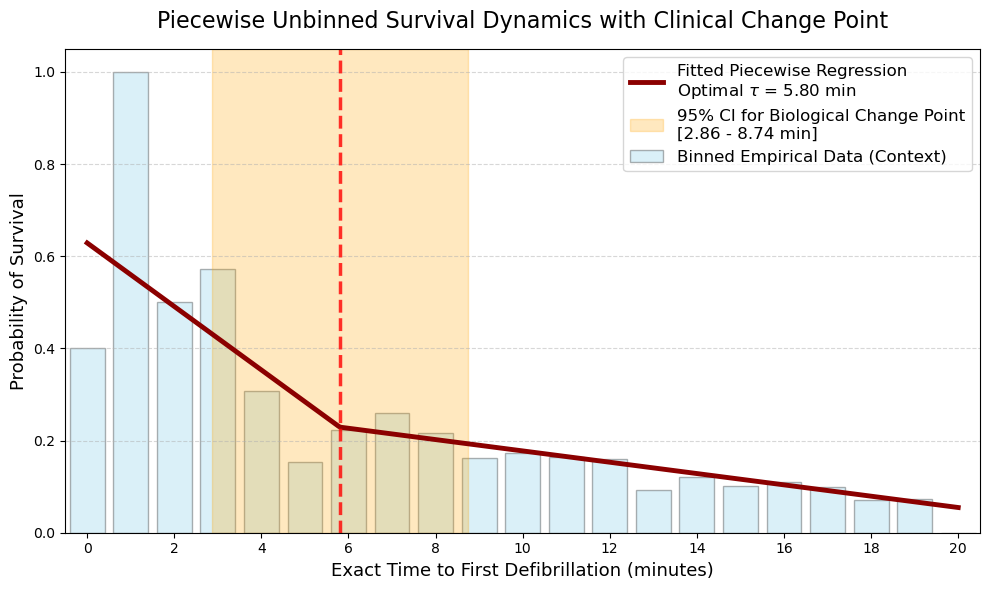

In [ ]:
plt.figure(figsize=(10, 6))

# Background bars for context (empirical probability)
plt.bar(binned_vis['Time_Bin'],
        binned_vis['Survival_Probability'], 
        width=0.8,
        alpha=0.3,
        color='skyblue',
        edgecolor='black', 
        label='Binned Empirical Data (Context)')

# Plot the "broken stick" piecewise lines
plt.plot(x_plot,
         y_plot,
         color='darkred',
         linewidth=3.5, 
         label=f'Fitted Piecewise Regression\nOptimal $\\tau$ = {tau_est:.2f} min')

# 6. Plot the Tau Intersection and Shade the 95% CI Region
plt.axvline(x=tau_est,
            color='red',
            linestyle='--',
            linewidth=2.5,
            alpha=0.8)

plt.axvspan(ci_lower,
            ci_upper,
            color='orange',
            alpha=0.25, 
            label=f'95% CI for Biological Change Point\n[{ci_lower:.2f} - {ci_upper:.2f} min]')

# Make it clinically readable
plt.title('Piecewise Unbinned Survival Dynamics with Clinical Change Point',
          fontsize=16,
          pad=15)
plt.xlabel('Exact Time to First Defibrillation (minutes)',
           fontsize=13)
plt.ylabel('Probability of Survival',
           fontsize=13)

plt.xlim(-0.5, 20.5)
plt.xticks(np.arange(0, 21, 2))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

plt.show()